# AWS

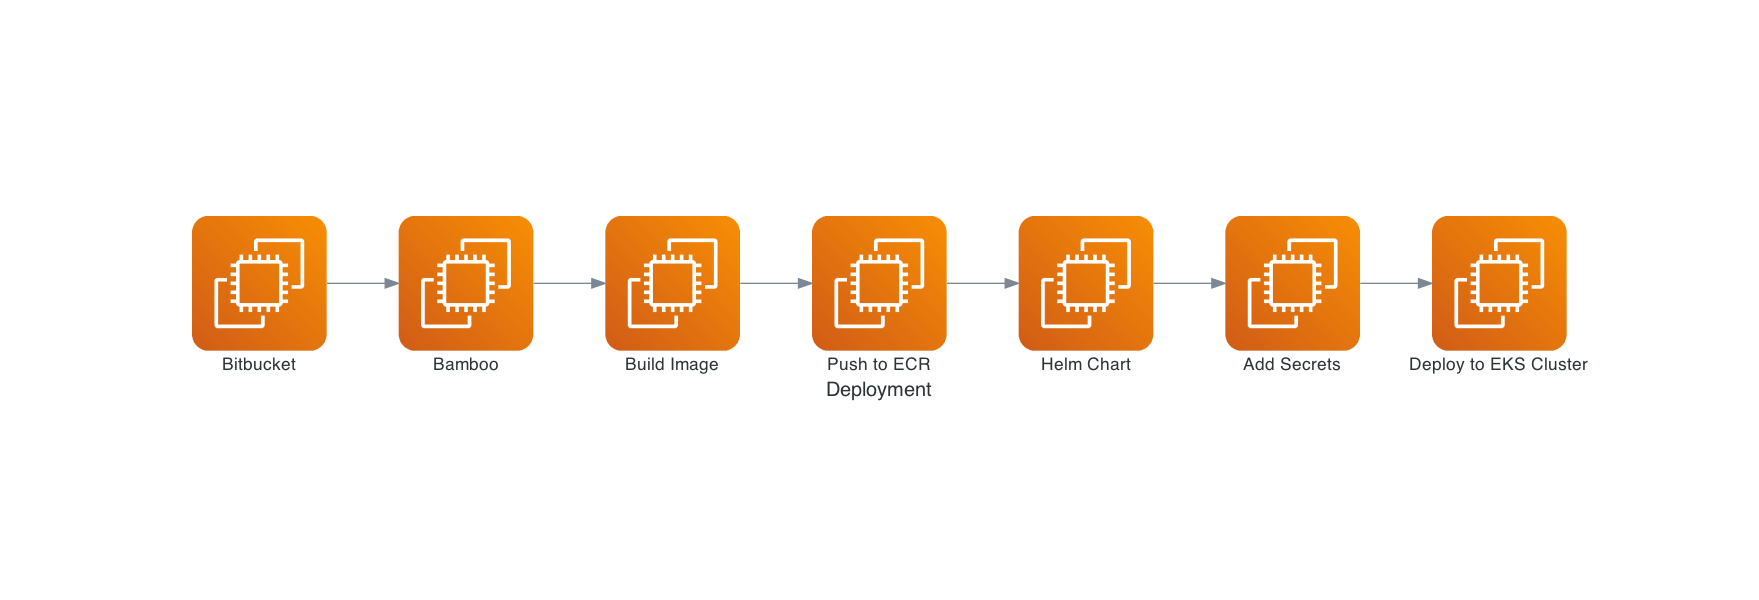

In [4]:
#!/usr/bin/env python3

#!/usr/bin/env python

from diagrams import Diagram
from diagrams.aws.compute import EC2, EKS
from diagrams.aws.database import RDS, Elasticache
from diagrams.aws.network import ELB, VPC

from diagrams import Cluster, Diagram
from diagrams.aws.compute import ECS, AutoScaling
from diagrams.aws.database import ElastiCache, RDS
from diagrams.aws.network import ELB
from diagrams.aws.network import Route53

with Diagram("Deployment", show=False) as diag:
    EC2("Bitbucket") >> EC2("Bamboo") >> EC2("Build Image") >> EC2("Push to ECR") >> EC2("Helm Chart") >> EC2("Add Secrets") >> EC2("Deploy to EKS Cluster")

diag


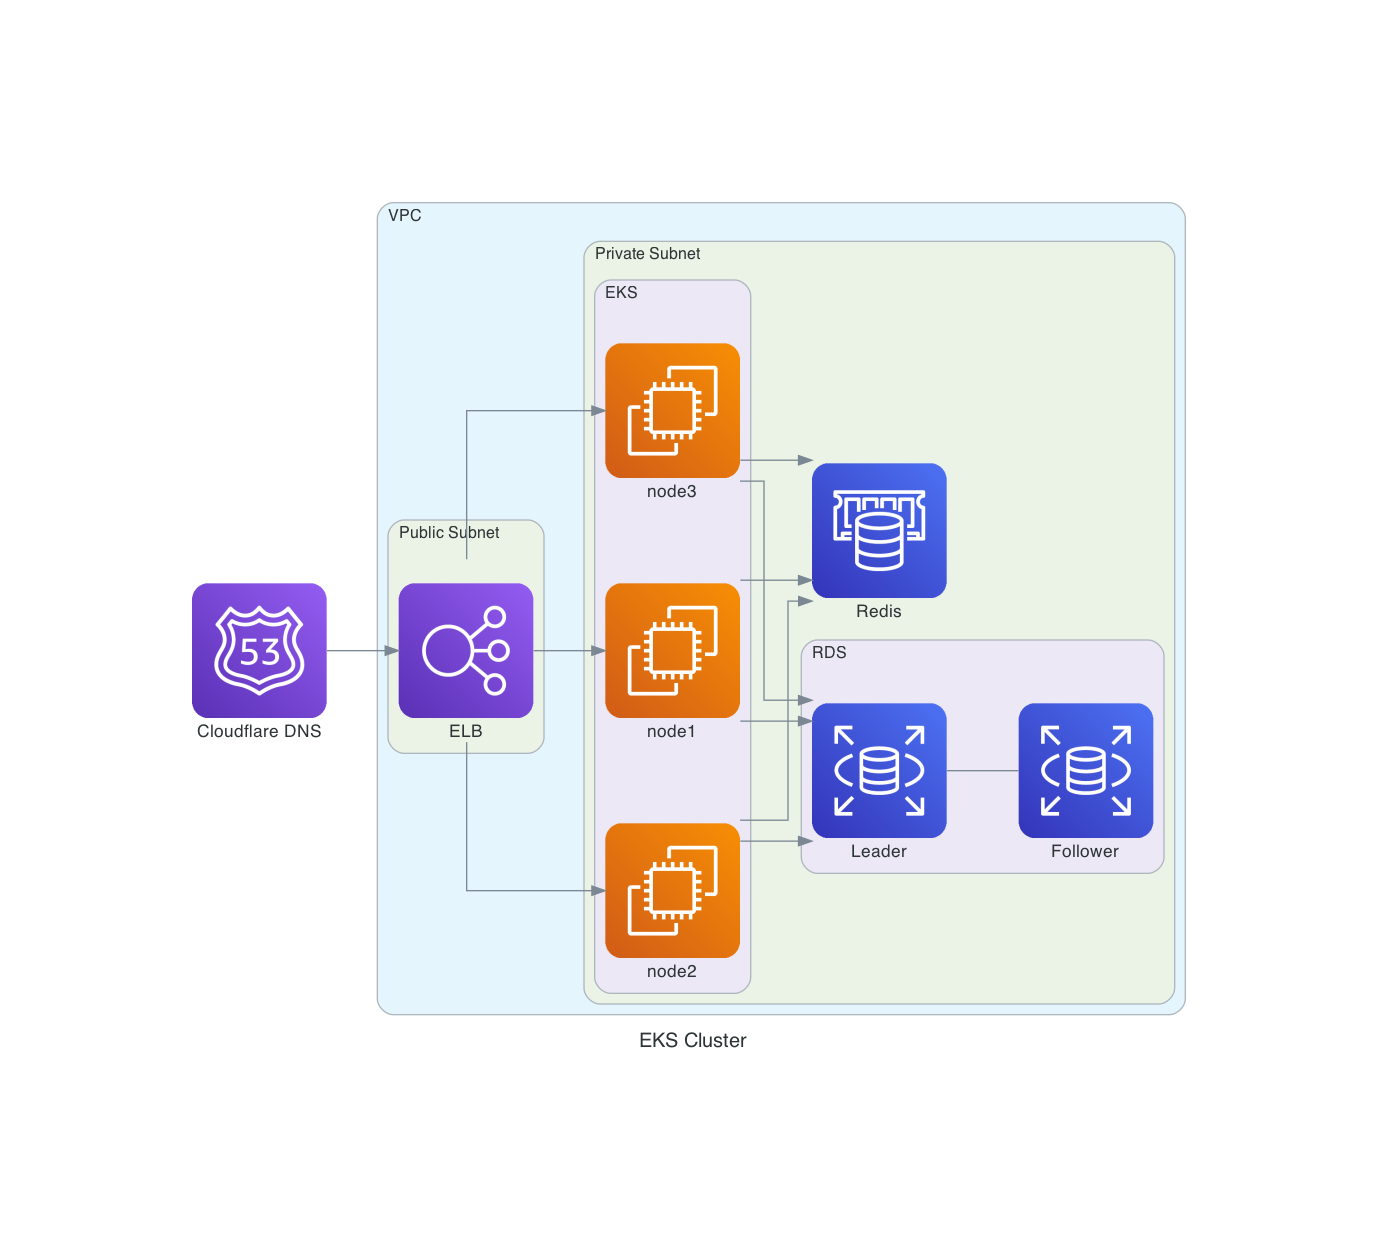

In [5]:
#!/usr/bin/env python

from diagrams import Diagram
from diagrams.aws.compute import EC2, EKS
from diagrams.aws.database import RDS, Elasticache
from diagrams.aws.network import ELB, VPC

from diagrams import Cluster, Diagram
from diagrams.aws.compute import ECS, AutoScaling
from diagrams.aws.database import ElastiCache, RDS
from diagrams.aws.network import ELB
from diagrams.aws.network import Route53

with Diagram("EKS Cluster", show=False) as diag:
    dns = Route53("Cloudflare DNS")

    with Cluster("VPC"):
        with Cluster("Public Subnet"):
            lb = ELB("ELB")

        with Cluster("Private Subnet"):
            with Cluster("EKS"):
                svc_group = [EC2("node1"),
                             EC2("node2"),
                             EC2("node3")]

            with Cluster("RDS"):
                db_master = RDS("Leader")
                db_master - [RDS("Follower")]

            redis = ElastiCache("Redis")

    dns >> lb >> svc_group
    svc_group >> db_master
    svc_group >> redis

diag

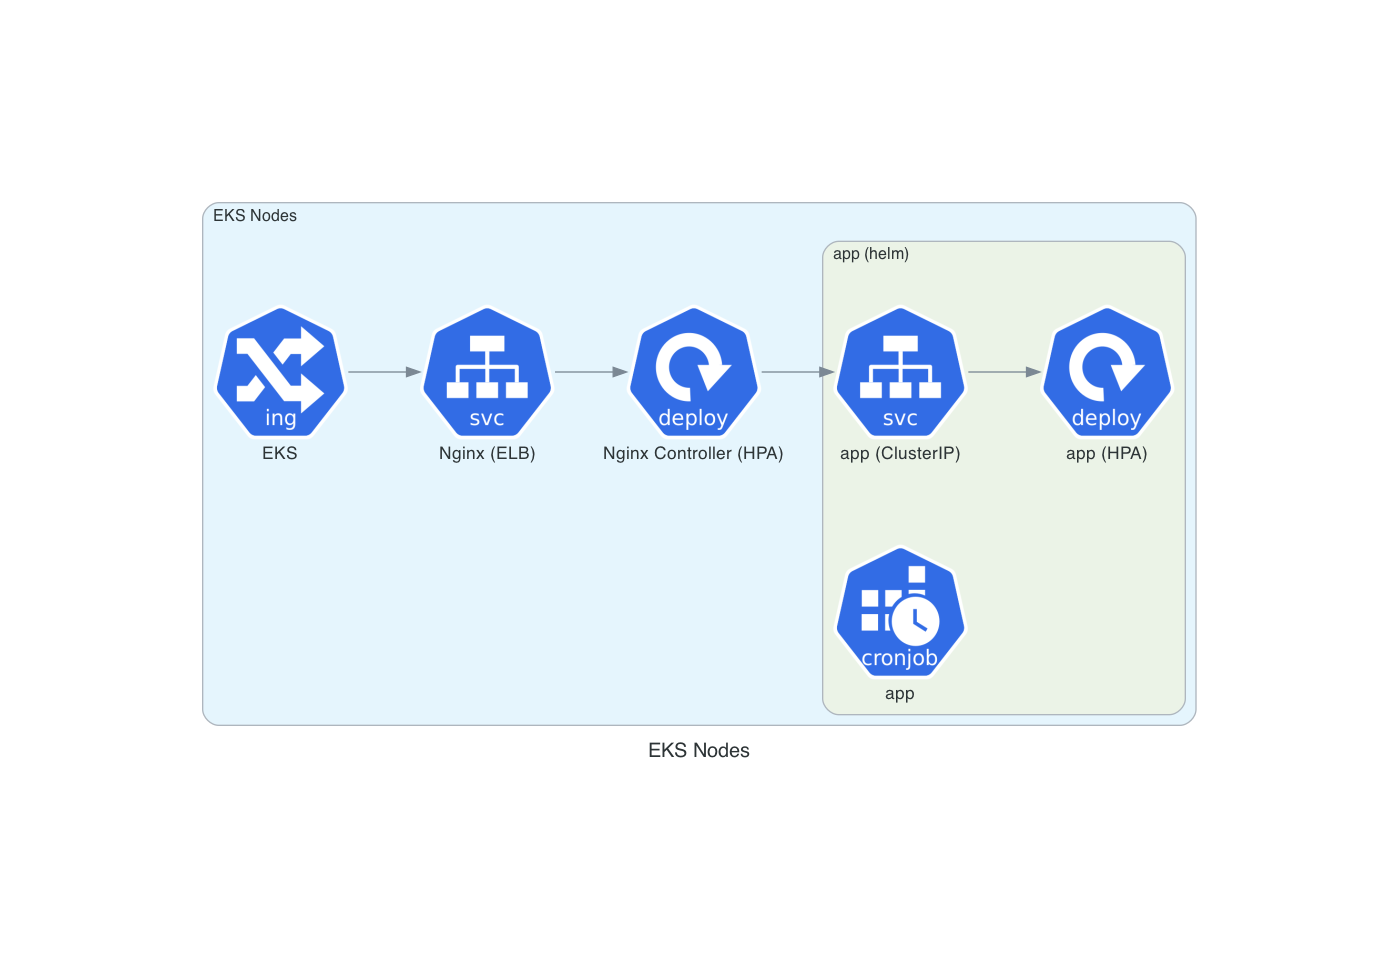

In [6]:
#!/usr/bin/env python

from diagrams import Cluster, Diagram
from diagrams.k8s.clusterconfig import HPA
from diagrams.k8s.compute import Deployment, Pod, ReplicaSet, Cronjob
from diagrams.k8s.network import Ingress, Service

with Diagram("EKS Nodes", show=False) as diag:
    with Cluster("EKS Nodes"):
        net = Ingress("EKS") >> Service("Nginx (ELB)") >> Deployment("Nginx Controller (HPA)")

        with Cluster("app (helm)"):
            net >> Service("app (ClusterIP)") >> [
                Deployment("app (HPA)"),
            ]
            Cronjob("app")

diag